After you've successfully acquired and cleaned your data, we will design an impulse.

# 1. Impulse Design: Create Impulse

An **Impulse** is the full end-to-end machine learning pipeline in Edge Impulse. It slices raw, continuous sensor data into uniform windows, extracts informative features using **digital signal processing (DSP)**, and passes those features to a **learning block** to classify the state.

Navigate to **Impulse Design** section -> **Create impulse** in the left sidebar.

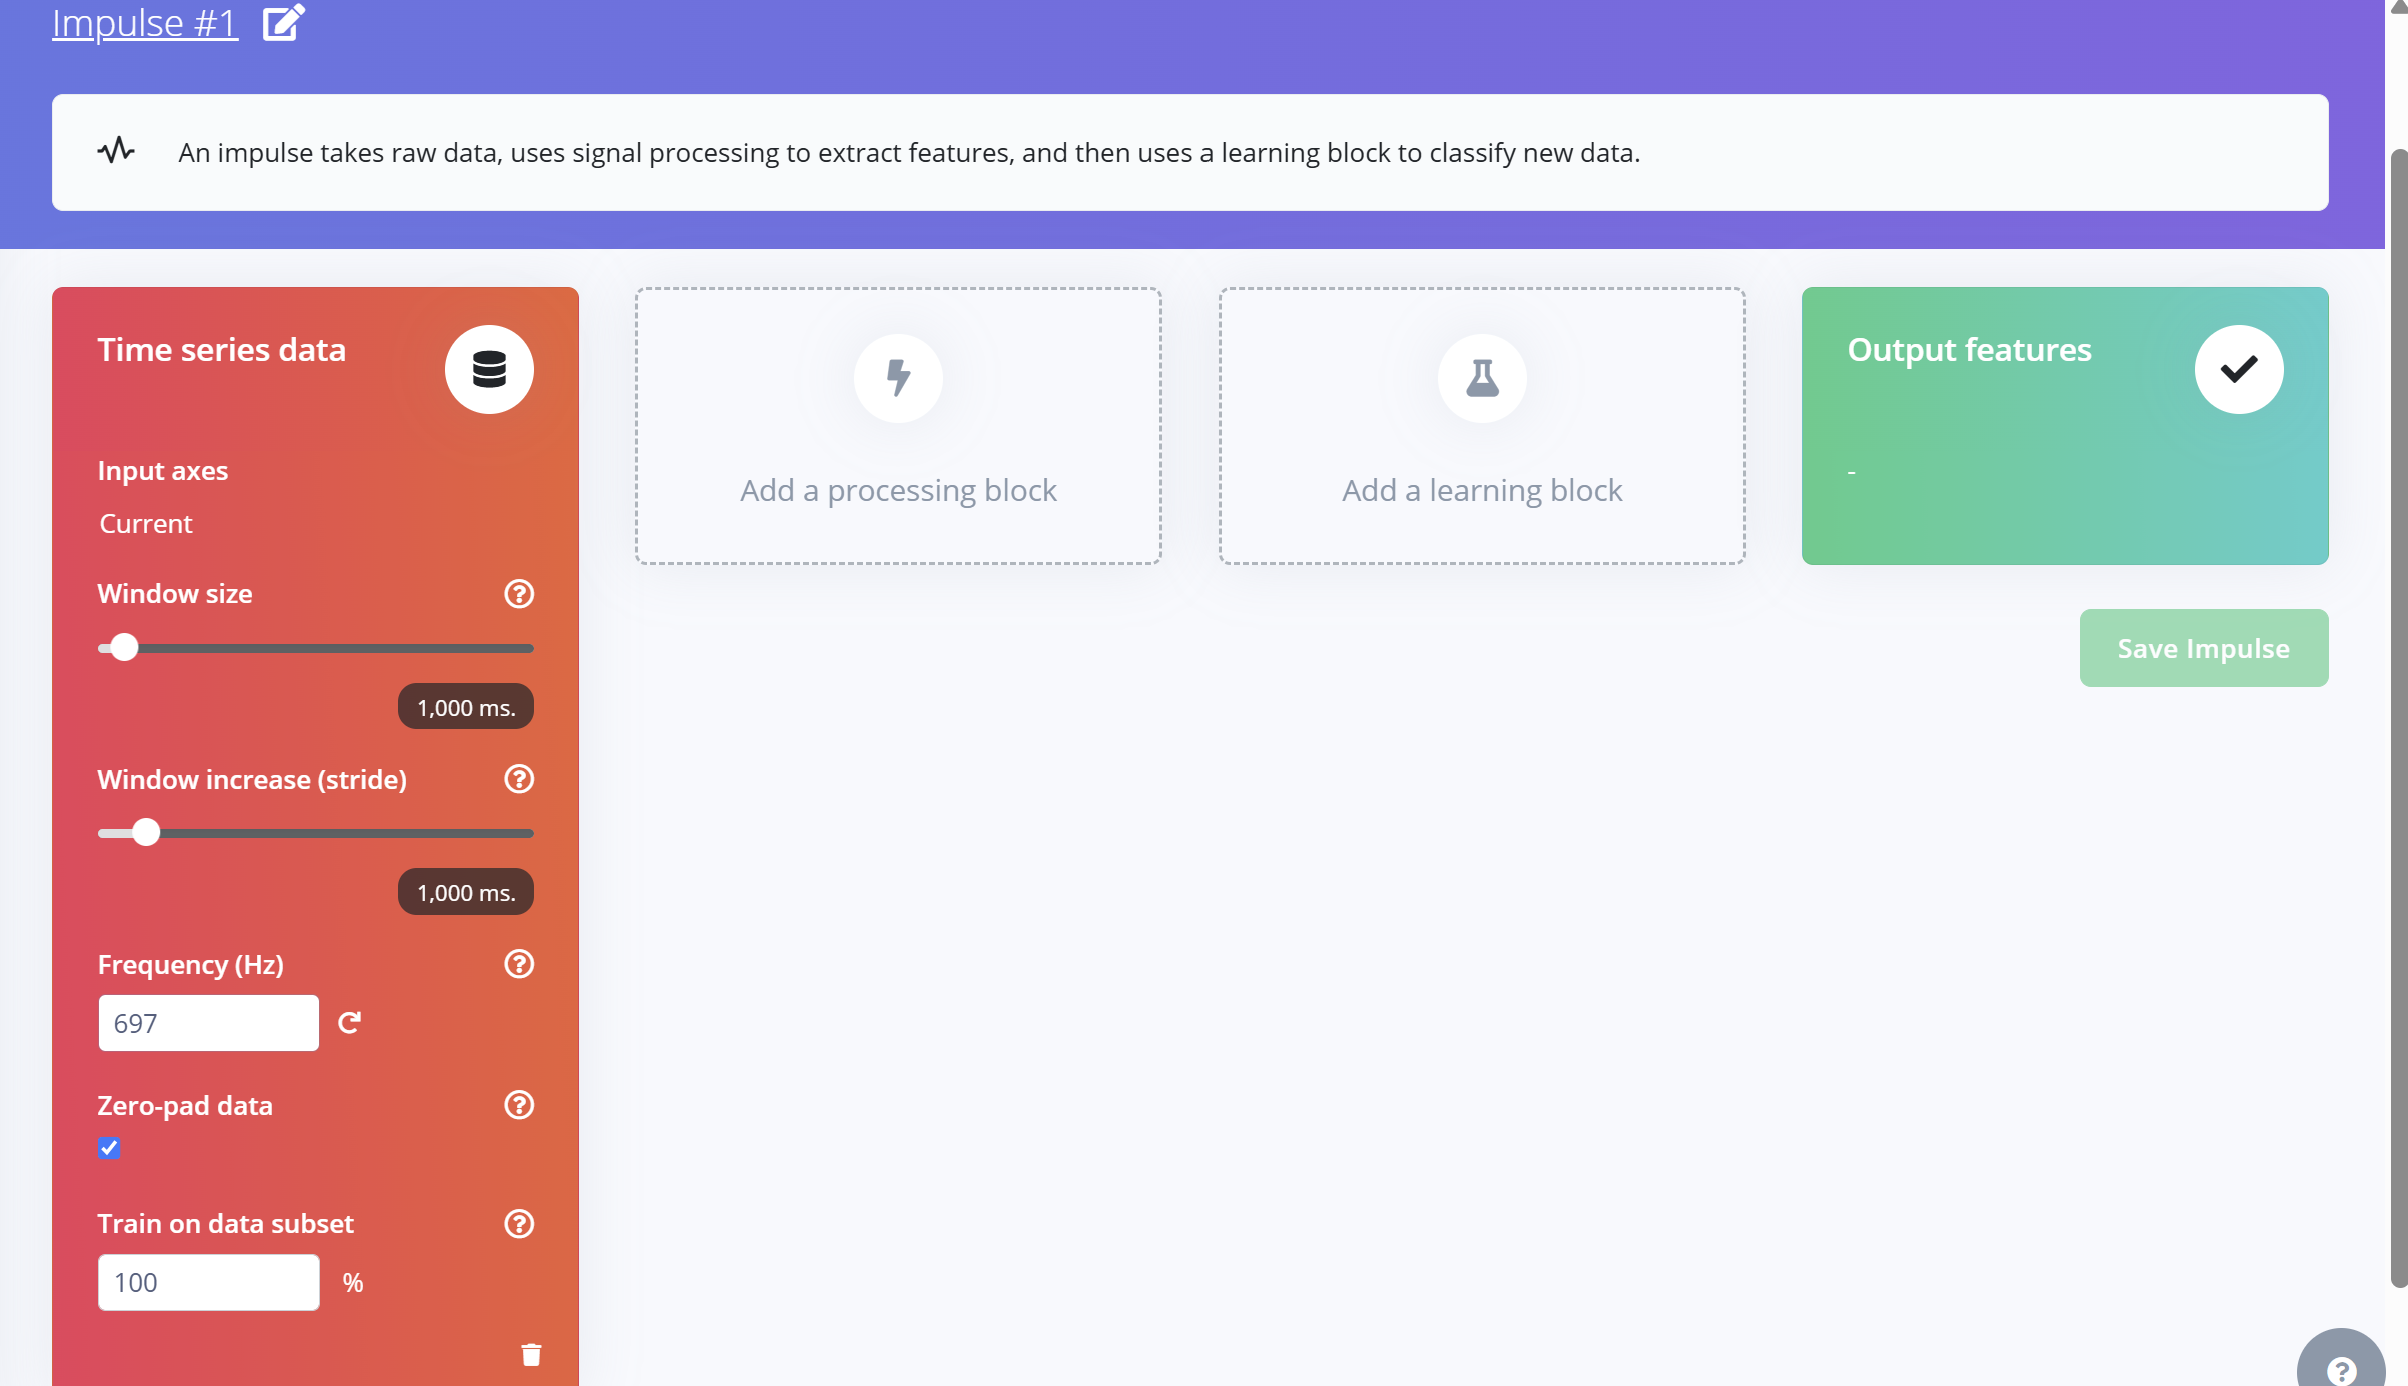

### Step 1: Time Series Data (Input Windowing)
The raw data block divides your continuous recordings into fixed-size training segments using a sliding window:

* **Window size:** The length of time (in milliseconds) the model looks at to make a single prediction (e.g., `1000 ms` or `2000 ms`). 
  * *Tip:* Choose a window long enough to capture a full behavioral cycle (such as the onset of a motor stall) without adding unnecessary latency.
* **Window increase (stride):** How far the window advances before creating the next slice (e.g., `500 ms`). 
  * Setting the stride smaller than the window size creates overlapping slices. This acts as **data augmentation**, expanding your effective dataset size without collecting extra samples.
* **Frequency:** Auto-populated based on your ingested dataset (e.g., `50 Hz` or `100 Hz`).


### Step 2: Add a Processing Block (Spectral Analysis)
Signal processing extracts key patterns so the neural network doesn't have to learn directly from noisy, raw waveforms:

1. Click **Add a processing block**.
2. Select **Spectral Analysis**.
   * *Why:* It computes statistical moments (RMS, skewness, kurtosis) and performs a Fast Fourier Transform (FFT) to convert time-domain sensor waveforms into the frequency domain. This is ideal for detecting repetitive vibrations, harmonic changes, and sudden current draw shifts.

<!-- _Read more [here]()._ -->

### Step 3: Add a Learning Block (Classification)
1. Click **Add a learning block**.
2. Select **Classification**.
   * This block takes the engineered frequency and statistical features and learns to map them to your target labels (e.g., `idle`, `stall`).


### Step 4: Save the Impulse
Ensure your input sensor axes (e.g., `current`) are checked, then click **Save Impulse**.


# 2. Feature Extraction: Spectral Features

Once the impulse is saved, click **Spectral features** under **Impulse design** in the left sidebar.

This page lets you tune filters, configure the FFT, inspect transformed waveforms, and generate the final feature matrix for training. This will also show you the raw data on top of the screen (you can select other files via the drop down menu), and the results of the signal processing through graphs on the right. For the spectral features block you’ll see the following graphs:

- Filter response - If you have chosen a filter (with non zero order), this will show you the response across frequencies. That is, it will show you how much each frequency will be attenuated.
- After filter - the signal after applying the filter. This will remove noise.
- Spectral power - Shows power vs. frequency as computed by the chosen FFT size. Power is either linear or log based on settings. This is shown if the selected analysis type is FFT

### Key Parameter Settings

1. **Filter:**
- **Scale axes:** Converts raw ADC integer readings into real physical units.
   - *Why it matters here:* If your microcontroller reads an analog current sensor and outputs digital values like `0` to `4095` or `0` to `1023`, you can multiply by a scale factor (e.g., 0.0008 or your sensor's sensitivity constant) to convert raw numbers into actual Amperes ($A$) or Milliamps ($mA$).
   - Scaling keeps the feature values within a standard, well-conditioned numerical range for the neural network.
- **Input decimation ratio:** Lowers the effective sampling rate by discarding intermediate readings.
   - *Why it matters here:* A motor stall is fundamentally a low-frequency DC surge—the current jumps to a high level and stays there as long as the rotor is held. You don't need kilohertz-level resolution to see a current spike. If you streamed data at $100\text{ Hz}$ or $200\text{ Hz}$, setting a decimation ratio of 2 or 4 drops it to $50\text{ Hz}$.
   - It drastically cuts down on the RAM and DSP compute cycles your microcontroller needs to run feature extraction, while still leaving more than enough resolution to catch the jump from idle to stall.
- **Type:** Isolates the stall signal from electrical noise.
   - Low Pass (Best for this): DC motors produce high frequency electrical noise. A low-pass filter smooths out those noisy spikes so the DSP block focuses purely on the overall jump in baseline current.
   - High-pass (Avoid here): A high-pass filter removes the steady DC baseline and only preserves rapid AC fluctuations. Because a sustained stall is a prolonged DC current shift, a high-pass filter would strip away the most obvious indicator of a stall.
   - None: Leaves the raw sensor waveform intact if your circuit already includes hardware RC low-pass filtering.

2. **Spectral Power (FFT Settings):**

   There are two types of analysis you can choose from.
      - FFT base analysis is best at analyzing repetitive patterns in a signal,
      - Wavelet works better for complex signals that have transients or irregular waveform.

- **Analysis type:** Keep as `FFT` (Fast Fourier Transform). Converts your time-based current signal into a frequency spectrum.
   - In idle mode, you get small periodic ripples from motor commutation; when stalled, the rotor halts, AC ripples drop out, and energy collapses into the zero-frequency (DC) band.
- **FFT length:** Determines the frequency resolution (e.g., `16`, `32`, `64`, or `128`).
   - *Trade-off:* Larger values yield finer frequency resolution but produce more input features, increasing peak RAM usage and model size on your microcontroller.
- **Take log of spectrum:** Enabled by default. Applies a $\log_{10}$ scale to the frequency bins, boosting the sensitivity of low-amplitude harmonics.
   - Compresses the scale logarithmically so massive current peaks don’t completely drown out the tiny, subtle electrical ripples present during normal idle spinning.
- **Overlap FFT frames:** Slices sub-windows with a 50% overlap to catch quick transient spikes occurring near frame boundaries. If unchecked, frames will not overlap. This “sliding frame” method can prevent transient events from being missed if they happen to appear on a frame boundary. Enabled by default. Disabling improves latency. No impact on model size or RAM usage.

3. **Save Parameters:**
   - After choosing your parameters, click **Save parameters** at the top or bottom of the configuration card.


### Generating and Validating Features

##### Data Normalization

<img src = "normalize.png" width = "50%">

_In some cases, you may want to normalize your data before training a model. This is especially useful when your data has different scales or units, as it can help improve the performance of your model._

1. Click the **Generate features** tab at the top of the screen.
2. Click the blue **Generate features** button.
   - Edge Impulse runs the DSP block across every training sample, outputting **feature vectors** containing both time-domain statistics (RMS, Skewness, Kurtosis) and frequency bin power values.

3. **Inspect the Feature Explorer:**

<img src = "feature_explorer.png" width = "50%">

   - Look at the 2D/3D scatter plot. Each dot represents a single window slice from your dataset.
   - **Good separation:** Clusters of different colors (e.g., green for `idle` and orange for `stall`) are grouped cleanly with noticeable distance between them.
   - **Overlapping clusters:** If data points from different classes overlap heavily, the model will struggle to differentiate them. Adjust your window size, tweak the FFT length, or check for mislabeled samples in your dataset.
      -  A good rule of thumb is that if you can visually identify some clusters by classes, then the machine learning model will be able to do so as well.

### Summary:

Raw Data $\rightarrow$ Processing Block (DSP) $\rightarrow$ Features $\rightarrow$ Learning Block (ML) $\rightarrow$ Prediction
